
# 02 — Multi-Recording Feature Engineering

## Research role

This notebook converts the full SinD package from **frame-level observations** into a single **trajectory-level analytical dataset**.

The uploaded package contains 56 recordings from Changchun, Chongqing, Tianjin, and Xi'an. A vehicle may appear in hundreds of consecutive frames, but the research question concerns the behavior of one complete observed intersection movement. Therefore, the unit of analysis must be one passenger-car trajectory rather than one frame.

## Learning objectives

After completing this notebook, you should be able to explain:

1. Why a trajectory must be represented by one analytical row.
2. Why `track_id` alone is not globally unique.
3. How speed, acceleration, braking, jerk, and stopping features are calculated.
4. Why short and full-record stationary trajectories are excluded.
5. Why exclusion decisions must be logged instead of silently deleting data.
6. Why Tianjin metadata is retained only for post-cluster interpretation.



## Methodological rationale

### Why not cluster individual frames?

Clustering frames would give long trajectories more influence because the same vehicle would appear many times. Adjacent frames are also strongly dependent and usually describe nearly identical motion states. A frame-level model would therefore identify instantaneous states, not complete behavioral profiles.

### Unique trajectory identifier

`track_id` can restart in every recording. The pipeline creates:

```text
trajectory_uid = city + "__" + recording_id + "__" + track_id
```

This prevents two different vehicles from different recordings from being merged accidentally.

### Core quality rules

A passenger-car trajectory is excluded when:

- its duration is below 5 seconds; or
- it traveled no more than 0.5 metres **and** never exceeded 0.1 m/s.

The stationary rule uses both distance and speed so that a vehicle waiting at a red light for only part of its trajectory is not removed.


In [1]:

from pathlib import Path
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_ROOT = Path("/mnt/data")  # Change this to your local raw ZIP directory.
RUN_PIPELINE = False          # Set True to rebuild every processed output.

pipeline_script = PROJECT_ROOT / "scripts" / "run_feature_pipeline.py"
feature_path = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "sind_full_core_behavior_features.csv"
)

if RUN_PIPELINE:
    subprocess.run(
        [
            sys.executable,
            str(pipeline_script),
            "--raw-root",
            str(RAW_ROOT),
            "--output-root",
            str(PROJECT_ROOT),
        ],
        check=True,
    )
else:
    print("Pipeline execution skipped because RUN_PIPELINE=False.")
    print("Set RUN_PIPELINE=True when the raw recording ZIPs are available.")
    print(f"Using existing output: {feature_path}")


Pipeline execution skipped because RUN_PIPELINE=False.
Set RUN_PIPELINE=True when the raw recording ZIPs are available.
Using existing output: /mnt/data/SinD_Full_Study_v2/data/processed/sind_full_core_behavior_features.csv



## Feature definitions

For each valid passenger-car trajectory, the pipeline calculates ten modeling features:

| Feature | Behavioral meaning |
|---|---|
| `mean_speed_mps` | General speed level |
| `max_speed_mps` | Highest observed speed |
| `speed_std_mps` | Variation in speed over the trajectory |
| `mean_long_acc_mps2` | General longitudinal acceleration/deceleration tendency |
| `max_acceleration_mps2` | Strongest positive acceleration |
| `max_deceleration_mps2` | Strongest braking magnitude |
| `acceleration_std_mps2` | Variation in longitudinal acceleration |
| `mean_abs_jerk_mps3` | Average abruptness of acceleration changes |
| `observed_stop_transition_count` | Number of observed moving-to-stopped transitions |
| `stopped_time_ratio` | Proportion of observed frames below 0.5 m/s |

The standard deviations use the complete observed trajectory as the population (`ddof=0`). Jerk is calculated only when the time difference between two consecutive observations is positive.


In [2]:

processed_dir = PROJECT_ROOT / "data" / "processed"
tables_dir = PROJECT_ROOT / "outputs" / "tables"

features = pd.read_csv(
    processed_dir / "sind_full_core_behavior_features.csv"
)
trajectory_summary = pd.read_csv(
    processed_dir / "passenger_car_trajectory_summary.csv"
)
exclusion_log = pd.read_csv(
    processed_dir / "trajectory_exclusion_log.csv"
)
recording_summary = pd.read_csv(
    tables_dir / "recording_processing_summary.csv"
)
city_summary = pd.read_csv(
    tables_dir / "city_processing_summary.csv"
)

print(f"All passenger-car trajectories: {len(trajectory_summary):,}")
print(f"Excluded unique trajectories: {len(exclusion_log):,}")
print(f"Modeling-eligible trajectories: {len(features):,}")
print(f"Recordings processed: {recording_summary['recording_id'].nunique()}")


All passenger-car trajectories: 20,704
Excluded unique trajectories: 756
Modeling-eligible trajectories: 19,948
Recordings processed: 56



## Output 1 — City-level processing summary

This table provides a complete data-accounting chain:

```text
raw vehicle data
→ passenger-car trajectories
→ quality flags
→ unique exclusions
→ final modeling population
```

The short and stationary flags can overlap, so `excluded_unique_trajectories` must be used instead of adding the two flag counts directly.


In [3]:

city_summary


,city,recordings,raw_vehicle_rows,raw_vehicle_trajectories,passenger_car_rows,passenger_car_trajectories,flagged_duration_below_minimum,flagged_stationary_full_trajectory,flag_overlap_short_and_stationary,excluded_unique_trajectories,modeling_eligible_trajectories
0,Changchun,8,3158641,10372,2769176,8774,88,30,9,109,8665
1,Chongqing,10,3080096,2691,2753742,2171,46,216,19,243,1928
2,Tianjin,23,3182723,11375,1321613,4752,151,73,5,219,4533
3,Xi'an,15,2630833,5931,2355450,5007,83,123,21,185,4822


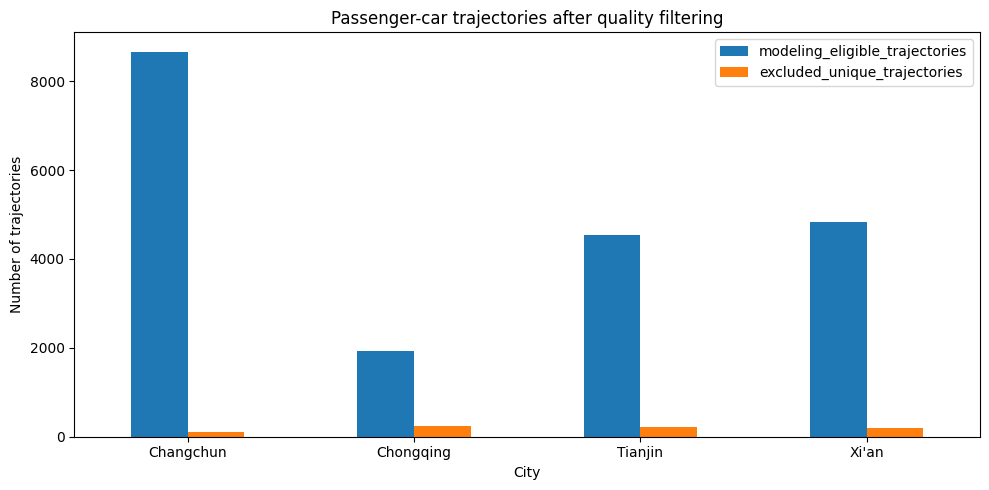

Saved figure: /mnt/data/SinD_Full_Study_v2/outputs/figures/trajectory_filtering_by_city.png


In [4]:

plot_data = city_summary.set_index("city")[
    ["modeling_eligible_trajectories", "excluded_unique_trajectories"]
]

ax = plot_data.plot(kind="bar", figsize=(10, 5))
ax.set_title("Passenger-car trajectories after quality filtering")
ax.set_xlabel("City")
ax.set_ylabel("Number of trajectories")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()

figure_path = (
    PROJECT_ROOT
    / "outputs"
    / "figures"
    / "trajectory_filtering_by_city.png"
)
plt.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

print(f"Saved figure: {figure_path}")



### Interpretation

The final dataset is not evenly distributed across cities. Changchun contributes the largest number of passenger-car trajectories, while Chongqing contributes the smallest. This imbalance is not an error, but it creates a modeling risk: pooled clustering may be influenced more strongly by cities with more trajectories.

Later experiments must therefore report both:

- pooled full-dataset results; and
- recording-level and city-level validation results.



## Output 2 — Transparent exclusion log

Every excluded trajectory remains traceable by city, recording, track ID, duration, distance, speed, and reason. This supports reproducibility and allows the group to defend its cleaning decisions.


In [5]:

exclusion_counts = (
    exclusion_log["exclusion_reason"]
    .value_counts()
    .rename_axis("exclusion_reason")
    .reset_index(name="trajectory_count")
)
exclusion_counts


,exclusion_reason,trajectory_count
0,stationary_full_trajectory,388
1,duration_below_5s,314
2,duration_below_5s; stationary_full_trajectory,54


In [6]:

exclusion_log.head(10)


,trajectory_uid,city,recording_id,track_id,source_archive,trajectory_duration_s,frame_count,travel_distance_m,max_speed_mps,flag_duration_below_minimum,flag_stationary_full_trajectory,exclusion_reason
0,Chongqing__6_22_NR_1__3,Chongqing,6_22_NR_1,3,6_22_NR_1.zip,2.902903,30,19.919671,7.159184,True,False,duration_below_5s
1,Chongqing__6_22_NR_1__5,Chongqing,6_22_NR_1,5,6_22_NR_1.zip,222.122122,2220,0.000000,0.000000,False,True,stationary_full_trajectory
2,Chongqing__6_22_NR_1__7,Chongqing,6_22_NR_1,7,6_22_NR_1.zip,1160.960961,11599,0.000000,0.000000,False,True,stationary_full_trajectory
3,Chongqing__6_22_NR_1__8,Chongqing,6_22_NR_1,8,6_22_NR_1.zip,221.821822,2217,0.000000,0.000000,False,True,stationary_full_trajectory
4,Chongqing__6_22_NR_1__9,Chongqing,6_22_NR_1,9,6_22_NR_1.zip,1160.960961,11599,0.000000,0.000000,False,True,stationary_full_trajectory
5,Chongqing__6_22_NR_1__10,Chongqing,6_22_NR_1,10,6_22_NR_1.zip,1160.960961,11599,0.000000,0.000000,False,True,stationary_full_trajectory
6,Chongqing__6_22_NR_1__11,Chongqing,6_22_NR_1,11,6_22_NR_1.zip,1160.960961,11599,0.000000,0.000000,False,True,stationary_full_trajectory
7,Chongqing__6_22_NR_1__12,Chongqing,6_22_NR_1,12,6_22_NR_1.zip,1160.960961,11599,0.000000,0.000000,False,True,stationary_full_trajectory
8,Chongqing__6_22_NR_1__13,Chongqing,6_22_NR_1,13,6_22_NR_1.zip,1160.960961,11599,0.000000,0.000000,False,True,stationary_full_trajectory
9,Chongqing__6_22_NR_1__14,Chongqing,6_22_NR_1,14,6_22_NR_1.zip,1160.960961,11599,0.000000,0.000000,False,True,stationary_full_trajectory



### Interpretation

The exclusion rules are deliberately conservative. A vehicle is not removed merely because it stopped. It is removed as stationary only if the **whole observed trajectory** contains almost no movement.

This distinction is essential because stopping at a traffic signal is one of the behaviors the study intends to discover.



## Output 3 — Final modeling table and quality gates

Before EDA or clustering, the final table must satisfy all of the following:

- one row per unique trajectory;
- no duplicate `trajectory_uid`;
- no missing values in the ten core features;
- no infinite values;
- all 56 recordings represented;
- no label or metadata variable included in the core feature list.


In [7]:

CORE_FEATURES = [
    "mean_speed_mps",
    "max_speed_mps",
    "speed_std_mps",
    "mean_long_acc_mps2",
    "max_acceleration_mps2",
    "max_deceleration_mps2",
    "acceleration_std_mps2",
    "mean_abs_jerk_mps3",
    "observed_stop_transition_count",
    "stopped_time_ratio",
]

assert features["trajectory_uid"].is_unique
assert features[CORE_FEATURES].isna().sum().sum() == 0
assert np.isinf(features[CORE_FEATURES].to_numpy()).sum() == 0
assert features["recording_id"].nunique() == 56
assert set(CORE_FEATURES).isdisjoint(
    {"CrossType", "Signal_Violation_Behavior", "class"}
)

print("All final modeling-table quality gates passed.")


All final modeling-table quality gates passed.


In [8]:

features.head()


,trajectory_uid,city,recording_id,track_id,source_archive,trajectory_duration_s,frame_count,travel_distance_m,position_span_m,mean_speed_mps,max_speed_mps,speed_std_mps,mean_long_acc_mps2,max_acceleration_mps2,max_deceleration_mps2,acceleration_std_mps2,mean_abs_jerk_mps3,observed_stop_transition_count,stopped_time_ratio,class,CrossType,Signal_Violation_Behavior
0,Chongqing__6_22_NR_1__26,Chongqing,6_22_NR_1,26,6_22_NR_1.zip,34.934935,350,58.651760,57.466154,1.670233,10.402213,3.048197,0.186535,3.280724,1.465814,0.768091,0.490549,1,0.705714,NaN,NaN,NaN
1,Chongqing__6_22_NR_1__27,Chongqing,6_22_NR_1,27,6_22_NR_1.zip,8.508509,86,57.611045,57.609232,6.799832,9.757802,2.048517,0.845947,1.571353,-0.000000,0.302063,0.389092,0,0.000000,NaN,NaN,NaN
2,Chongqing__6_22_NR_1__28,Chongqing,6_22_NR_1,28,6_22_NR_1.zip,44.244244,443,89.893474,89.218914,2.029552,11.275787,3.215059,0.099963,1.639189,1.187419,0.652187,0.254256,1,0.623025,NaN,NaN,NaN
3,Chongqing__6_22_NR_1__29,Chongqing,6_22_NR_1,29,6_22_NR_1.zip,41.541542,416,66.301902,55.964776,1.586128,9.940657,2.637214,0.080159,3.079156,1.441627,0.757237,0.406370,1,0.687500,NaN,NaN,NaN
4,Chongqing__6_22_NR_1__30,Chongqing,6_22_NR_1,30,6_22_NR_1.zip,41.841842,419,90.921893,90.178448,2.181280,10.527757,3.169058,0.097040,1.061651,1.996332,0.615741,0.253535,1,0.577566,NaN,NaN,NaN



## Optional metadata and the unsupervised design

`CrossType` and `Signal_Violation_Behavior` are available only for Tianjin in the uploaded package. They are retained as optional reference variables but are **not** part of the ten modeling features.

This preserves the unsupervised research design:

- the model discovers groups from motion characteristics;
- metadata is examined only after clustering to interpret the groups;
- the analysis does not pretend that equivalent labels exist for all four cities.


In [9]:

metadata_availability = (
    features.groupby("city")
    .agg(
        trajectories=("trajectory_uid", "count"),
        cross_type_available=("CrossType", lambda values: values.notna().sum()),
        violation_label_available=(
            "Signal_Violation_Behavior",
            lambda values: values.notna().sum(),
        ),
    )
)
metadata_availability


,trajectories,cross_type_available,violation_label_available
city,,,
Changchun,8665,0,0
Chongqing,1928,0,0
Tianjin,4533,4533,4533
Xi'an,4822,0,0



## Preliminary feature inspection

This is not yet the formal EDA. It is a safety check to identify whether the full dataset contains extreme values that may influence distance-based clustering.


In [10]:

feature_statistics = (
    features[CORE_FEATURES]
    .agg(["min", "median", "mean", "max"])
    .T
)
feature_statistics


,min,median,mean,max
mean_speed_mps,0.022036,5.216623,5.353730,22.372928
max_speed_mps,0.898105,9.965982,10.084620,99.466762
speed_std_mps,0.048426,2.039976,2.100883,6.263775
mean_long_acc_mps2,-1.718072,0.123991,0.157115,2.308666
max_acceleration_mps2,0.000000,1.555751,1.960201,126.185481
max_deceleration_mps2,-0.000000,1.426473,1.533011,115.736161
acceleration_std_mps2,0.055932,0.666785,0.733408,8.071731
mean_abs_jerk_mps3,0.008006,0.479493,0.555202,6.552034
observed_stop_transition_count,0.000000,0.000000,0.493934,15.000000
stopped_time_ratio,0.000000,0.000000,0.208046,0.995190



### Interpretation

The final table is structurally valid, but some maximum speed, acceleration, and deceleration values are much larger than typical values. These observations must not be deleted automatically because they may represent:

- rare but real aggressive movement;
- trajectory-boundary artifacts;
- smoothing or coordinate-estimation errors;
- a small number of extreme measurements within otherwise valid trajectories.

The next notebook must perform full EDA, compare distributions by city and recording, inspect representative extreme trajectories, and decide whether winsorization, robust scaling, or another treatment is justified.

## Notebook conclusion

The multi-recording pipeline successfully converts 56 recordings into a reproducible trajectory-level master dataset.

- Passenger-car trajectories before filtering: **20,704**
- Unique excluded trajectories: **756**
- Final modeling-eligible trajectories: **19,948**
- Duplicate trajectory IDs: **0**
- Missing core feature values: **0**
- Infinite core feature values: **0**

The dataset is now ready for **full-dataset EDA**, not yet for final model training.



## Questions you should be able to answer

1. **Why is each trajectory one row?**  
   Because the research concerns complete observed driving behavior, and frame-level clustering would overrepresent long trajectories.

2. **Why is `trajectory_uid` necessary?**  
   Because `track_id` is only unique inside one recording.

3. **Why remove trajectories below five seconds?**  
   They provide too little temporal evidence for stable speed, acceleration, jerk, and stopping summaries.

4. **Why not remove every stopped vehicle?**  
   Stopping is a meaningful behavior at signalized intersections. Only trajectories that remain nearly stationary for the full observation are excluded.

5. **Why are `CrossType` and violation labels not model inputs?**  
   Using them would change the task from unsupervised behavior discovery into label-guided grouping and would also make the four-city analysis inconsistent.
